# Peak architecture sweep - results (nested oracle/surrogate split, in-silico-test)

Same style as `archive/esm2_design/sweep_results.ipynb` (archived), run against the **nested** split built by
`make_dual_split.py` instead of the main pipeline's coordinated dual split: oracle is
80/10/10 of the whole dataset, and surrogate is a 70/15/15 split carved *only* from
oracle-train (so oracle's val/test are held out from the surrogate entirely).

Label = `BACKBONE (depth) - pooling` (`None` = depth-0 pool-only baseline). Color = pooling,
marker = backbone.

Pooling readouts: `mean / max / concat / concatstd / attn`, plus **`cov`** -- a learned
covariance-probe pool ($z_i = W^\top x_i$, then $C_z = \tfrac{1}{L}\sum_i z_i z_i^\top$
flattened over its upper triangle) added on CNN depth 1-3.

Per role: leaderboard table, val-MAE barplot (embedding-NN k-sweep null models pinned at the
top, outside the ranking), a val-vs-test scatter, and pred-vs-truth scatters for the top-3
configs on the validation and test sets (MAE + R$^2$ in each corner).

The null is always run under the **same protocol as the bars it is pinned against**: on the
surrogate boards, where every bar is a 3-fold CV mean, the null goes through those same folds
(`cv_embed_nulls`, 24.7 nm at *k*=1); on the oracle board, which was never cross-validated, both
sides use the single 80/10/10 split (`embed_nulls`, 16.7 nm). Mixing the two would compare a null
fitted on 424 (or 606) proteins against configs fitted on a fold's 343.

In [1]:
# Shared loaders + plotters. Each sweep is read straight from its checkpoints.
import glob, os
import numpy as np, pandas as pd, torch
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FS = 12
plt.rcParams.update({"font.size": FS, "axes.titlesize": FS, "axes.labelsize": FS,
                     "xtick.labelsize": FS, "ytick.labelsize": FS, "legend.fontsize": FS})

BB = {"cnn": "CNN", "transformer": "TF", "mlp": "None"}
POOL_C = {"mean": "#9a9a9a", "max": "#2b6c8f", "concat": "#f6a200", "concatstd": "#c5474b",
          "attn": "#3b8a6e", "cov": "#7a5ea8", "null": "#111111"}   # cov = covariance-probe pool
ARCH_M = {"mlp": "o", "cnn": "s", "transformer": "^"}
POOL_ORDER = ["mean", "max", "concat", "concatstd", "attn", "cov"]

def load_sweep(out_dir):
    recs = []
    for p in glob.glob(f"{out_dir}/*.pt"):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        r = dict(arch=ck["arch"], pool=ck["pool"], depth=ck.get("depth"), seed=ck["seed"],
                 val_mae=ck["val_mae"], test_mae=ck["test_mae"],
                 label=f"{BB[ck['arch']]} ({ck.get('depth')}) - {ck['pool']}")
        if "val_ex" in ck:
            r["val_ex"] = ck["val_ex"]; r["val_em"] = ck["val_em"]
        recs.append(r)
    if not recs:                                                # no .pt weights -> fall back to the sweep's results.csv
        csv_path = os.path.join(out_dir, "results.csv")
        if os.path.exists(csv_path):
            s = pd.read_csv(csv_path)
            vm = "val_mae_mean" if "val_mae_mean" in s else "val_mae"        # per-role sweeps use *_mean/_std
            tm = "test_mae_mean" if "test_mae_mean" in s else "test_mae"     # single-seed scalar sweeps: bare cols
            out = pd.DataFrame({
                "label": [f"{BB[a]} ({d}) - {po}" for a, po, d in zip(s["arch"], s["pool"], s["depth"])],
                "arch": s["arch"], "pool": s["pool"], "depth": s["depth"],
                "n_seeds": s["n_seeds"] if "n_seeds" in s else 1,
                "val_mae": s[vm], "val_std": s.get("val_mae_std", 0.0),
                "test_mae": s[tm], "test_std": s.get("test_mae_std", 0.0)})
            print(f"(no .pt in {out_dir}; read leaderboard from results.csv -- null baseline & pred-vs-truth need checkpoints)")
            return out.sort_values("val_mae").reset_index(drop=True)
        print(f"(no checkpoints or results.csv in {out_dir} yet)"); return None
    df = pd.DataFrame(recs)
    aggd = {"n_seeds": ("seed", "nunique"), "val_mae": ("val_mae", "mean"), "val_std": ("val_mae", "std"),
            "test_mae": ("test_mae", "mean"), "test_std": ("test_mae", "std")}
    if "val_ex" in df:
        aggd.update(val_ex=("val_ex", "mean"), val_em=("val_em", "mean"))
    agg = df.groupby(["label", "arch", "pool", "depth"]).agg(**aggd).reset_index()
    agg[["val_std", "test_std"]] = agg[["val_std", "test_std"]].fillna(0.0)
    return agg.sort_values("val_mae").reset_index(drop=True)

def show_table(agg):
    if agg is None: return "no checkpoints yet"
    cols = ["label", "arch", "pool", "depth", "n_seeds", "val_mae", "val_std", "test_mae", "test_std"]
    if "val_ex" in agg: cols += ["val_ex", "val_em"]
    return agg[cols].round(3)

def plot_bar(agg, unit, title, nulls=None):
    if agg is None: print("no data"); return
    cfg = agg[["label", "pool", "val_mae", "val_std"]].sort_values("val_mae", ascending=False).reset_index(drop=True)
    yc = np.arange(len(cfg))
    gap = 1.0
    n_null = len(nulls) if nulls else 0
    total = len(cfg) + (n_null + gap if n_null else 0)
    fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.2 * total)))
    _xerr = cfg["val_std"].to_numpy()
    _show_err = bool(np.nanmax(_xerr) > 0)                       # single-seed sweeps have std 0 -> no error bars/caps
    ax.barh(yc, cfg["val_mae"], xerr=(_xerr if _show_err else None), capsize=(2 if _show_err else 0),
            edgecolor="black", linewidth=0.3, color=[POOL_C.get(p, "#333") for p in cfg["pool"]])
    yticks, ylabels = list(yc), list(cfg["label"])
    if nulls:                                                    # null models pinned ABOVE the ranking
        items = list(nulls.items())
        yn = np.arange(n_null) + len(cfg) + gap
        ax.barh(yn, [v for _, v in items], color=POOL_C["null"], edgecolor="black", linewidth=0.3)
        ax.axhline(len(cfg) - 0.5 + gap / 2, ls=":", color="0.5", lw=1)
        yticks += list(yn); ylabels += [k for k, _ in items]
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=FS)
    ax.set_xlabel(f"validation MAE ({unit})"); ax.set_title(title)
    handles = [Patch(color=POOL_C[p], label=p) for p in POOL_ORDER]
    if nulls: handles.append(Patch(color=POOL_C["null"], label="NN null"))
    ax.legend(handles=handles, title="pooling", fontsize=FS, title_fontsize=FS)
    ax.tick_params(labelsize=FS); ax.margins(y=0.01); plt.tight_layout(); plt.show()

def _legends(ax):
    ah = [Line2D([], [], marker=m, color="w", markerfacecolor="gray", markeredgecolor="k",
                 markersize=10, label=BB[a]) for a, m in ARCH_M.items()]
    l1 = ax.legend(handles=ah, title="backbone", fontsize=FS, title_fontsize=FS, loc="upper left"); ax.add_artist(l1)
    ax.legend(handles=[Patch(color=POOL_C[p], label=p) for p in POOL_ORDER],
              title="pooling", fontsize=FS, title_fontsize=FS, loc="lower right")

def plot_scatter(agg, unit, per_peak=False):
    if agg is None: print("no data"); return
    n = 2 if (per_peak and "val_ex" in agg) else 1
    fig, ax = plt.subplots(1, n, figsize=(6.5 * n, 5.8)); ax = np.atleast_1d(ax)
    for arch, m in ARCH_M.items():
        s = agg[agg.arch == arch]
        ax[0].scatter(s["val_mae"], s["test_mae"], marker=m, s=75, edgecolor="black", linewidth=0.4,
                      c=[POOL_C.get(p) for p in s["pool"]])
    lo, hi = agg[["val_mae", "test_mae"]].values.min(), agg[["val_mae", "test_mae"]].values.max()
    pad = 0.05 * (hi - lo + 1e-9); lim = [lo - pad, hi + pad]
    ax[0].plot(lim, lim, "k--", lw=1)
    b = agg.iloc[0]
    ax[0].annotate(b["label"], (b["val_mae"], b["test_mae"]), fontsize=FS, xytext=(5, 5), textcoords="offset points")
    ax[0].set_xlabel(f"val MAE ({unit})"); ax[0].set_ylabel(f"test MAE ({unit})")
    ax[0].set_title("val vs test  (marker = backbone, color = pooling)"); _legends(ax[0])
    if n == 2:
        for arch, m in ARCH_M.items():
            s = agg[agg.arch == arch]
            ax[1].scatter(s["val_ex"], s["val_em"], marker=m, s=75, edgecolor="black", linewidth=0.4,
                          c=[POOL_C.get(p) for p in s["pool"]])
        l2 = [min(agg.val_ex.min(), agg.val_em.min()) - 1, max(agg.val_ex.max(), agg.val_em.max()) + 1]
        ax[1].plot(l2, l2, "k--", lw=1)
        ax[1].set_xlabel("ex_max val MAE (nm)"); ax[1].set_ylabel("em_max val MAE (nm)")
        ax[1].set_title("per-peak difficulty (below y=x: em easier than ex)")
    plt.tight_layout(); plt.show()

In [2]:
# experiment root + vendored lib on the import path (stage scripts live one level down)
import sys, os
for _p in ("", "lib", "msa", "1_surrogate_oracle_training"):
    _a = os.path.abspath(_p)
    if _a not in sys.path: sys.path.insert(0, _a)

# Prediction + baseline machinery: reuse THIS folder's sweep module (nested split) to load
# each role's embeddings/split, run checkpoints on the validation/test set, and compute an
# embedding-NN k-sweep null model. Peak-only (surrogate + oracle) -- no scalar-design traits here.
import peak_models as pm
import sweep_peak_oracle as swp   # this folder's wrapper: same code as esm2_design's, nested split
from sklearn.neighbors import NearestNeighbors
dev = swp.device()
_DATA = {}
K_SWEEP = [1, 3, 5, 10, 20]

_PEAK_ROLE = {"peak_surrogate": "surrogate", "peak_oracle": "oracle"}

def get_data(task):
    if task not in _DATA:
        _DATA[task] = (swp.load_data(_PEAK_ROLE[task], dev), 2)
    return _DATA[task]

def truth(D, task):
    return D["Pk"].cpu().numpy()

def raw_label(r): return f"{r['arch']}-{r['pool']}-d{r['depth']}"

def predict(ckpt, D, idx, out):
    base_net, ck = pm.load_model(ckpt, dev, out=out)
    net = pm.wrap(base_net, ck["mean"], ck["std"], dev); net.eval()
    ps = []
    with torch.no_grad():
        for i in range(0, len(idx), 64):
            b = idx[i:i + 64]
            mk = (D["ar"].unsqueeze(0) < torch.tensor(D["Ls"][b]).unsqueeze(1)).to(dev)
            ps.append(net(D["Ht"][b].float().to(dev), mk).cpu().numpy())
    return np.concatenate(ps)

def pooled_embed(D):
    return np.stack([D["Ht"][i, :int(D["Ls"][i])].float().numpy().mean(0)
                     for i in range(D["N"])]).astype(np.float32)

def nn_predict(X, y, tr, va, k):
    nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X[tr])
    idxs = nn.kneighbors(X[va], return_distance=False)
    return y[tr][idxs].mean(axis=1)

def r2(p, t): return 1.0 - np.sum((p - t) ** 2) / np.sum((t - t.mean()) ** 2)

def embed_nulls(task, ks=K_SWEEP):
    """Single-split null: fit on the role's train split, score on its val split. Protocol-matched
    to the SINGLE-SPLIT sweep boards (and to the oracle, which was never cross-validated)."""
    try:
        (D, out) = get_data(task)
    except FileNotFoundError:
        print(f"(skipping NN null for {task}: embedding cache not built here)"); return None
    X = pooled_embed(D); y = truth(D, task); T = y[D["va"]]
    return {f"NN k={k}": float(np.abs(nn_predict(X, y, D["tr"], D["va"], k) - T).mean()) for k in ks}


def cv_embed_nulls(task, ks=K_SWEEP, n_folds=3, fold_seed=0):
    """Same null, run through the SAME 3-fold partition as cv_all_surrogate.py: pool =
    concat(train, val) in that order, KFold(shuffle=True, random_state=0), neighbours fitted on
    each fold's train part and scored on its held-out part. Use this wherever the bars being
    compared are CV numbers -- the single-split null fits on the full 424-row train split while a
    CV config only ever sees a fold's 343, and a retrieval baseline gains directly with the number
    of proteins it can match against, so mixing the two compares data sizes rather than methods.
    Returns {label: mean over folds}; the per-fold SD is printed, since plot_bar takes no null
    error bars."""
    from sklearn.model_selection import KFold
    try:
        (D, out) = get_data(task)
    except FileNotFoundError:
        print(f"(skipping CV NN null for {task}: embedding cache not built here)"); return None
    X = pooled_embed(D); y = truth(D, task)
    pool = np.concatenate([D["tr"], D["va"]])
    folds = list(KFold(n_splits=n_folds, shuffle=True, random_state=fold_seed).split(pool))
    out_d = {}
    for k in ks:
        per_fold = [float(np.abs(nn_predict(X, y, pool[tri], pool[vai], k) - y[pool[vai]]).mean())
                    for tri, vai in folds]
        out_d[f"NN k={k}"] = float(np.mean(per_fold))
        print(f"  CV null {k:2}-NN: {np.mean(per_fold):5.2f} +/- {np.std(per_fold, ddof=1):4.2f} nm "
              f"(single split: {embed_nulls(task, [k])[f'NN k={k}']:5.2f} nm)")
    return out_d

def pred_vs_truth(task, agg, out_dir, split="va"):
    if agg is None: print("no data"); return
    if not glob.glob(os.path.join(out_dir, "*_s0.pt")):        # need per-config checkpoints to run predictions
        print(f"(skipping pred-vs-truth for {task}: no checkpoints in {out_dir})"); return
    try:
        (D, out) = get_data(task)
    except FileNotFoundError:
        print(f"(skipping pred-vs-truth for {task}: embedding cache not built here)"); return
    y = truth(D, task); idx = D[split]
    split_name = {"va": "validation", "te": "test", "tr": "train"}.get(split, split)
    top3 = agg.head(3)
    cols = ["ex_max (nm)", "em_max (nm)"]
    fig, axes = plt.subplots(3, 2, figsize=(4.8 * 2, 4.6 * 3)); axes = np.atleast_2d(axes)
    for i, (_, r) in enumerate(top3.iterrows()):
        P = predict(os.path.join(out_dir, f"{raw_label(r)}_s0.pt"), D, idx, out)
        for j, cname in enumerate(cols):
            ax = axes[i, j]
            p = P[:, j]; t = y[idx][:, j]
            lim = [min(p.min(), t.min()), max(p.max(), t.max())]
            ax.plot(lim, lim, "k--", lw=1)
            ax.scatter(t, p, s=20, alpha=0.7, color=POOL_C.get(r["pool"], "#333"), edgecolor="k", linewidth=0.3)
            ax.text(0.96, 0.04, f"MAE={np.abs(p - t).mean():.2f}\nR$^2$={r2(p, t):.2f}",
                    transform=ax.transAxes, ha="right", va="bottom", fontsize=FS,
                    bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
            ax.set_xlabel(f"true {cname}"); ax.set_ylabel(f"predicted {cname}")
            ax.set_title(r["label"], fontsize=FS); ax.set_box_aspect(1)
    plt.suptitle(f"{task}: top-3 configs, predictions on {split_name} set", y=1.005, fontsize=FS)
    plt.tight_layout(); plt.show()

## Peak - surrogate model (ESM-2 embedding, surrogate split: 70/15/15 carved from oracle-train)

train=424 / val=91 / test=91. This model never sees the 152 rows held out for oracle val/test.

In [3]:
peak_surr = load_sweep("trained_models/surrogate_sweep")
show_table(peak_surr)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std,val_ex,val_em
0,CNN (2) - concat,cnn,concat,2,1,11.420,0.0,19.511,0.0,13.263,9.577
1,CNN (2) - max,cnn,max,2,1,11.430,0.0,15.140,0.0,12.951,9.909
2,CNN (1) - concat,cnn,concat,1,1,11.480,0.0,18.567,0.0,13.672,9.287
3,CNN (1) - max,cnn,max,1,1,11.693,0.0,17.625,0.0,13.068,10.317
4,CNN (2) - concatstd,cnn,concatstd,2,1,11.798,0.0,18.773,0.0,13.658,9.938
5,CNN (4) - concat,cnn,concat,4,1,12.438,0.0,21.618,0.0,14.654,10.221
6,CNN (1) - concatstd,cnn,concatstd,1,1,12.545,0.0,18.731,0.0,14.287,10.802
7,CNN (1) - attn,cnn,attn,1,1,12.614,0.0,20.801,0.0,15.200,10.028
8,TF (1) - concatstd,transformer,concatstd,1,1,12.740,0.0,21.599,0.0,15.111,10.369
9,CNN (3) - concatstd,cnn,concatstd,3,1,12.926,0.0,21.011,0.0,14.543,11.309


In [4]:
import re

def _to_display_label(raw):                        # "cnn-concat-d2" -> "CNN (2) - concat", matching peak_surr's labels
    m = re.match(r"^([a-z]+)-([a-z]+)-d(\d+)$", raw)
    arch, pool, depth = m.group(1), m.group(2), int(m.group(3))
    return f"{BB[arch]} ({depth}) - {pool}"

cv3 = pd.read_csv("trained_models/surrogate_cv3.csv")
cv3["label"] = cv3["label"].map(_to_display_label)
cv_agg = cv3.groupby("label").agg(cv_va_mean=("fold_va_mae", "mean"), cv_va_std=("fold_va_mae", "std"),
                                  cv_test_mean=("fixed_test_mae", "mean"), cv_test_std=("fixed_test_mae", "std")
                                  ).reset_index()

# Incorporate the 3-fold CV into the full sweep board: cv_all_surrogate.py ran CV on ALL 48 configs
# (cv_surrogate_top5.py's original 5 + the remaining 43), so cv_agg now covers the whole grid --
# every row's single-split val/test MAE is replaced by the more robust CV mean +/- std, and the
# board is re-sorted by it. Unlike the earlier top-5-only version, this is now an apples-to-apples
# comparison: every config shown here has been through the same 3-fold stress test.
peak_surr_cv = peak_surr.copy()
for _, r in cv_agg.iterrows():
    m = peak_surr_cv["label"] == r["label"]
    peak_surr_cv.loc[m, "val_mae"] = r["cv_va_mean"]; peak_surr_cv.loc[m, "val_std"] = r["cv_va_std"]
    peak_surr_cv.loc[m, "test_mae"] = r["cv_test_mean"]; peak_surr_cv.loc[m, "test_std"] = r["cv_test_std"]
assert peak_surr_cv["val_std"].gt(0).all(), "expected CV coverage for every config"
peak_surr_cv = peak_surr_cv.sort_values("val_mae").reset_index(drop=True)

cv_cmp = cv_agg.merge(peak_surr[["label", "pool", "val_mae", "test_mae"]], on="label"
                     ).rename(columns={"val_mae": "single_split_val", "test_mae": "single_split_test"}
                     ).sort_values("cv_va_mean").reset_index(drop=True)

show_table(peak_surr_cv).head(10)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std,val_ex,val_em
0,CNN (1) - max,cnn,max,1,1,15.344,1.367,18.765,2.184,13.068,10.317
1,CNN (1) - concatstd,cnn,concatstd,1,1,15.620,1.517,19.236,2.217,14.287,10.802
2,CNN (2) - concat,cnn,concat,2,1,15.649,1.111,19.181,2.468,13.263,9.577
3,CNN (2) - max,cnn,max,2,1,15.750,0.833,19.057,1.918,12.951,9.909
4,CNN (2) - concatstd,cnn,concatstd,2,1,15.833,1.367,18.970,2.915,13.658,9.938
5,CNN (1) - concat,cnn,concat,1,1,16.090,1.473,19.677,2.468,13.672,9.287
6,TF (2) - max,transformer,max,2,1,16.751,1.425,21.031,2.312,15.371,11.688
7,CNN (1) - attn,cnn,attn,1,1,16.861,1.285,21.995,1.968,15.200,10.028
8,TF (1) - max,transformer,max,1,1,17.060,1.753,19.807,1.962,15.153,10.938
9,TF (1) - concatstd,transformer,concatstd,1,1,17.228,2.004,20.619,1.648,15.111,10.369


  CV null  1-NN: 24.69 +/- 3.20 nm (single split: 19.99 nm)


  CV null  3-NN: 25.73 +/- 1.24 nm (single split: 20.50 nm)


  CV null  5-NN: 25.77 +/- 2.42 nm (single split: 21.74 nm)


  CV null 10-NN: 27.48 +/- 2.35 nm (single split: 21.92 nm)


  CV null 20-NN: 29.18 +/- 1.97 nm (single split: 23.52 nm)


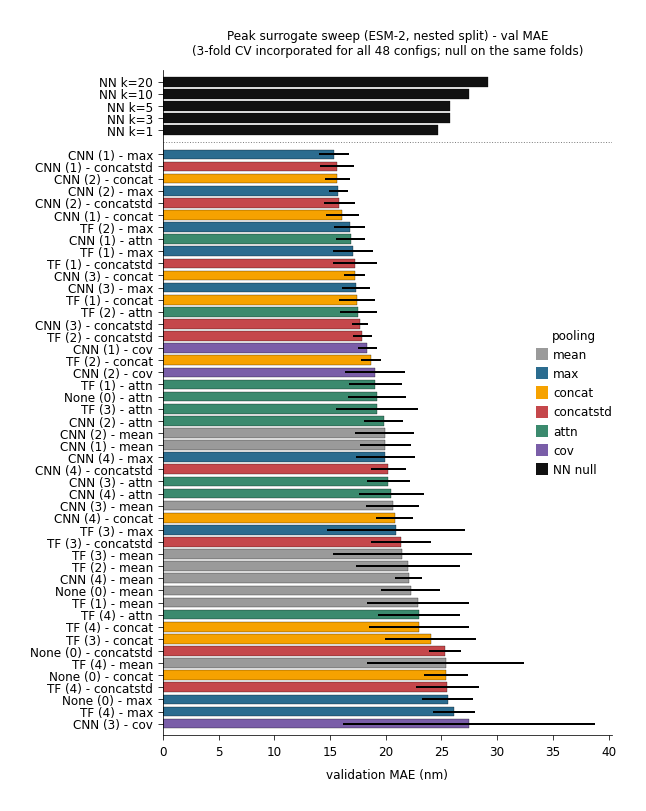

In [5]:
# Null run through the SAME folds as the bars it is pinned against (see cv_embed_nulls).
plot_bar(peak_surr_cv, "nm", "Peak surrogate sweep (ESM-2, nested split) - val MAE\n"
                            "(3-fold CV incorporated for all 48 configs; null on the same folds)",
        nulls=cv_embed_nulls("peak_surrogate"))

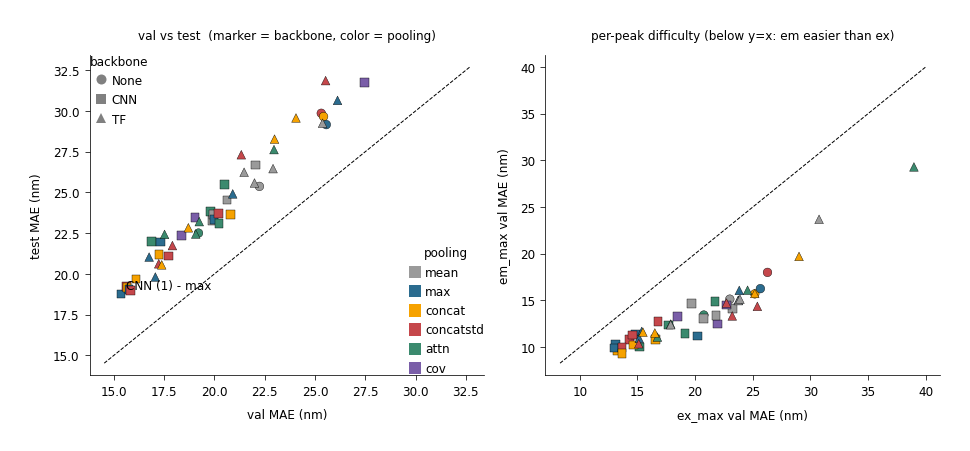

In [6]:
plot_scatter(peak_surr_cv, "nm", per_peak=True)

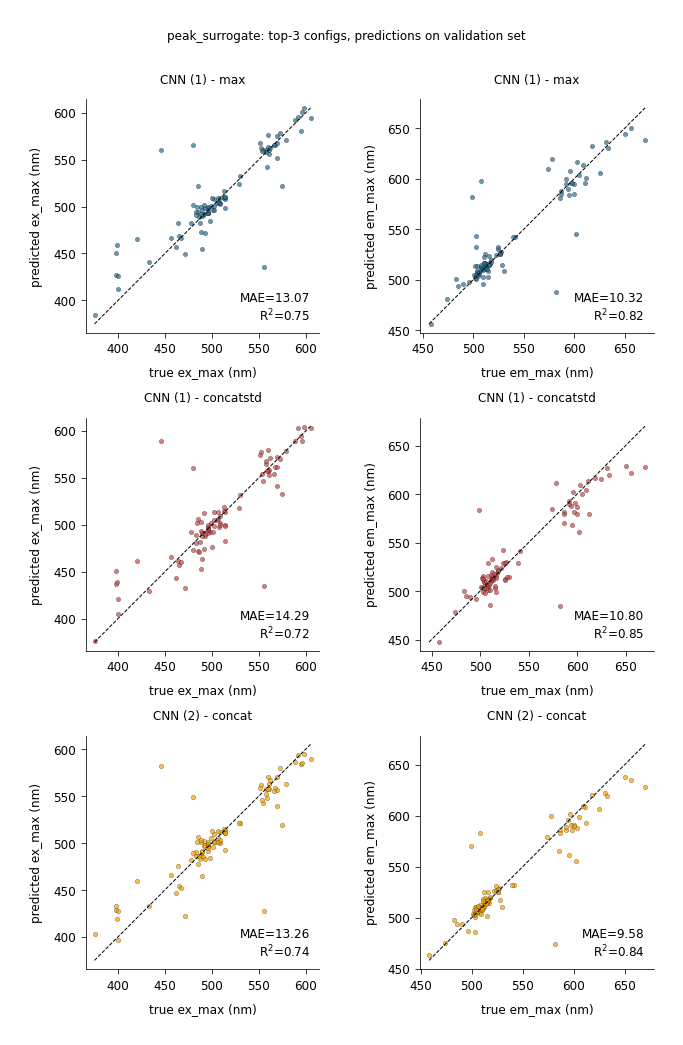

In [7]:
pred_vs_truth("peak_surrogate", peak_surr_cv, "trained_models/surrogate_sweep")

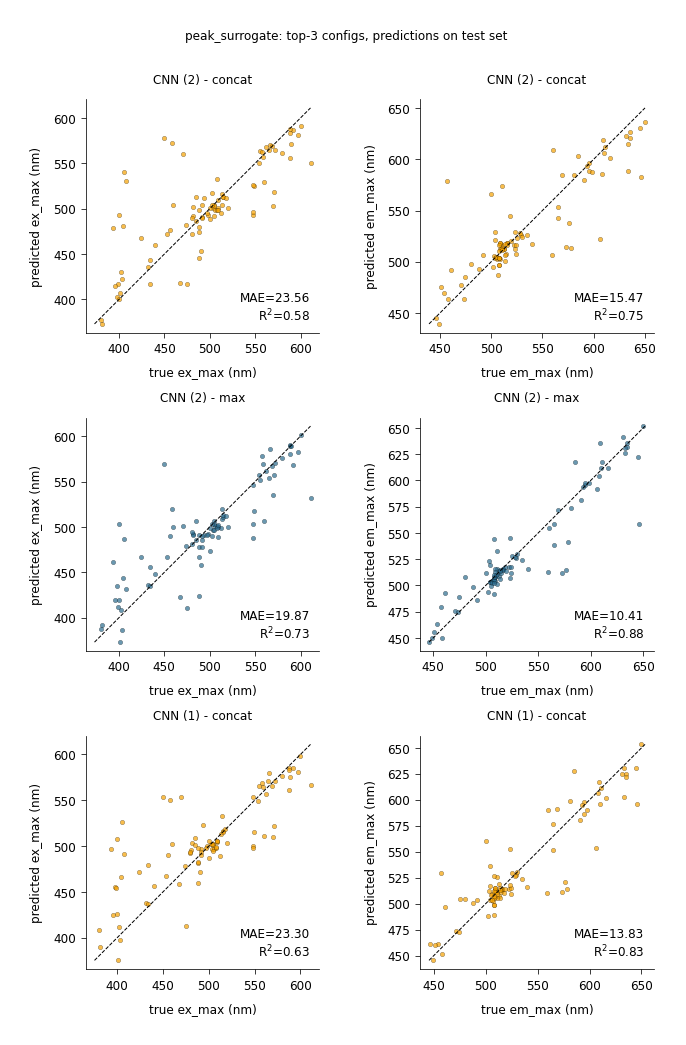

In [8]:
pred_vs_truth("peak_surrogate", peak_surr, "trained_models/surrogate_sweep", split="te")

### 3-fold CV on all 48 surrogate configs (naive random folds)

`cv_surrogate_top5.py` (first 5 configs) + `cv_all_surrogate.py` (remaining 43, reusing those
5's results since both use the same `FOLD_SEED`): pool = surrogate train ∪ val (515 rows), 3
naive-random `KFold` folds (~343 train / ~172 held-out each), per-fold standardization. The
91-row surrogate test is left completely untouched throughout and evaluated once per fold-model
as a **fixed common yardstick**, so all 48 configs × 3 folds are compared against the exact same
91 sequences.

The CV numbers are already incorporated into the main sweep board, scatter and pred-vs-truth
(val) above -- `peak_surr_cv` swaps every config's single-split val/test MAE for its 3-fold CV
mean ± std. Since CV now covers the whole grid (not just a top-5 subset), that re-sort is a
clean apples-to-apples ranking. Below: the full comparison table, a zoomed-in top-10 bar chart
(the full 48-bar version above is harder to read closely), and a per-fold view for the same
top-10, isolating fold-driven vs. config-driven variance.

No sequence-identity clustering (naive random, consistent with this experiment's split) --
this repo's `archive/esm2_design/cluster_split/run_oracle_cv.py` (archived) found that near-duplicate FP variants
(point mutants of the same parent scaffold) can leak across naive-random folds and optimistically
bias the held-out MAE, so treat these numbers as an upper bound on true generalization, not a
floor.

One config broke during fitting: `cnn-cov-d3` collapsed on one of its three folds (never escaped
its random init) -- combined with the oracle sweep's `cnn-cov-d3` failing outright, the
covariance-probe pool looks specifically unstable at depth 3.

In [9]:
# cv3 / cv_agg / cv_cmp / peak_surr_cv were already built above (right after peak_surr loaded) so
# the full sweep board, scatter and pred-vs-truth(val) could incorporate the CV numbers directly.
# cv_cmp now covers all 48 configs; show the top 10 by CV rank here (full table in surrogate_cv3.csv).
cv_cmp.head(10).round(2)

,label,cv_va_mean,cv_va_std,cv_test_mean,cv_test_std,pool,single_split_val,single_split_test
0,CNN (1) - max,15.34,1.37,18.77,2.18,max,11.69,17.62
1,CNN (1) - concatstd,15.62,1.52,19.24,2.22,concatstd,12.54,18.73
2,CNN (2) - concat,15.65,1.11,19.18,2.47,concat,11.42,19.51
3,CNN (2) - max,15.75,0.83,19.06,1.92,max,11.43,15.14
4,CNN (2) - concatstd,15.83,1.37,18.97,2.91,concatstd,11.80,18.77
5,CNN (1) - concat,16.09,1.47,19.68,2.47,concat,11.48,18.57
6,TF (2) - max,16.75,1.42,21.03,2.31,max,13.53,20.00
7,CNN (1) - attn,16.86,1.28,21.99,1.97,attn,12.61,20.80
8,TF (1) - max,17.06,1.75,19.81,1.96,max,13.05,19.99
9,TF (1) - concatstd,17.23,2.00,20.62,1.65,concatstd,12.74,21.60


  CV null  1-NN: 24.69 +/- 3.20 nm (single split: 19.99 nm)


  CV null  3-NN: 25.73 +/- 1.24 nm (single split: 20.50 nm)


  CV null  5-NN: 25.77 +/- 2.42 nm (single split: 21.74 nm)


  CV null 10-NN: 27.48 +/- 2.35 nm (single split: 21.92 nm)


  CV null 20-NN: 29.18 +/- 1.97 nm (single split: 23.52 nm)


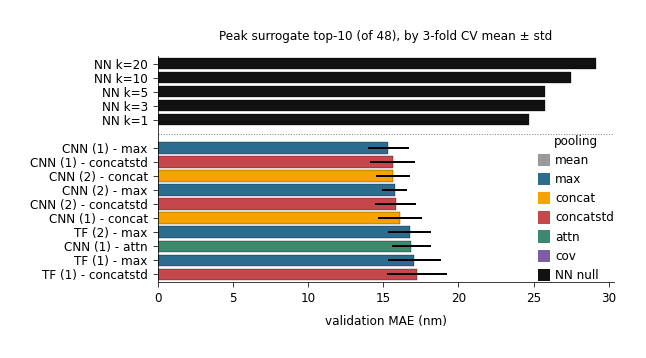

In [10]:
# Zoomed-in view: top-10 by 3-fold CV mean, with error bars -- reuses plot_bar unmodified.
peak_surr_cv10 = (cv_cmp.head(10)[["label", "pool", "cv_va_mean", "cv_va_std"]]
                 .rename(columns={"cv_va_mean": "val_mae", "cv_va_std": "val_std"})
                 .sort_values("val_mae").reset_index(drop=True))
plot_bar(peak_surr_cv10, "nm", "Peak surrogate top-10 (of 48), by 3-fold CV mean ± std",
        nulls=cv_embed_nulls("peak_surrogate"))

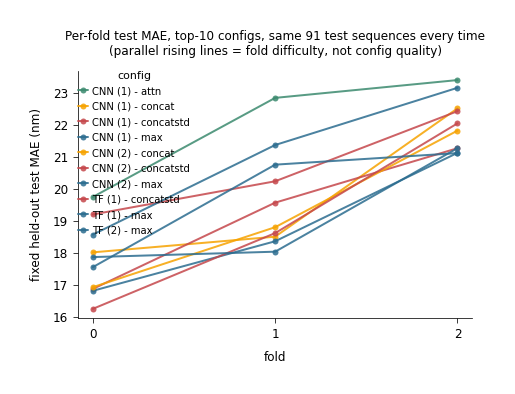

In [11]:
def plot_fold_effect(cv3_df, unit):
    """One line per config across fold 0/1/2, evaluated on the SAME fixed held-out test set --
    isolates whether variation is config-driven or fold-driven (a systematic rise = fold-driven,
    i.e. some fold's training subset is just harder, independent of which config was fit to it)."""
    fig, ax = plt.subplots(figsize=(6.5, 5))
    for lab, g in cv3_df.sort_values("fold").groupby("label"):
        pool = g["label"].iloc[0].split(" - ")[-1]
        ax.plot(g["fold"], g["fixed_test_mae"], marker="o", color=POOL_C.get(pool, "#333"),
                label=lab, alpha=0.85)
    ax.set_xticks(sorted(cv3_df["fold"].unique()))
    ax.set_xlabel("fold"); ax.set_ylabel(f"fixed held-out test MAE ({unit})")
    ax.set_title("Per-fold test MAE, top-10 configs, same 91 test sequences every time\n"
                "(parallel rising lines = fold difficulty, not config quality)")
    ax.legend(fontsize=FS - 2, title="config", title_fontsize=FS - 1)
    plt.tight_layout(); plt.show()

# restrict to the top-10 (of 48) for a legible legend -- the full 48-config version is unreadable
plot_fold_effect(cv3[cv3["label"].isin(cv_cmp.head(10)["label"])], "nm")

## Peak - oracle model (ProstT5 embedding, oracle split: 80/10/10 of the whole dataset)

train=606 / val=76 / test=76.

In [12]:
peak_orac = load_sweep("trained_models/oracle_sweep")
show_table(peak_orac)

,label,arch,pool,depth,n_seeds,val_mae,val_std,test_mae,test_std,val_ex,val_em
0,CNN (1) - max,cnn,max,1,1,8.710,0.0,12.273,0.0,10.378,7.042
1,CNN (2) - max,cnn,max,2,1,8.903,0.0,14.885,0.0,10.443,7.362
2,TF (3) - concat,transformer,concat,3,1,9.052,0.0,13.487,0.0,11.349,6.755
3,CNN (2) - concatstd,cnn,concatstd,2,1,9.264,0.0,13.749,0.0,11.312,7.216
4,TF (1) - concatstd,transformer,concatstd,1,1,9.309,0.0,13.553,0.0,11.033,7.584
5,TF (1) - concat,transformer,concat,1,1,9.388,0.0,14.022,0.0,11.909,6.867
6,CNN (2) - concat,cnn,concat,2,1,9.406,0.0,15.164,0.0,11.188,7.623
7,CNN (3) - concat,cnn,concat,3,1,9.436,0.0,12.478,0.0,11.434,7.439
8,TF (2) - concat,transformer,concat,2,1,9.468,0.0,14.298,0.0,11.700,7.237
9,CNN (3) - max,cnn,max,3,1,9.472,0.0,13.295,0.0,11.920,7.023


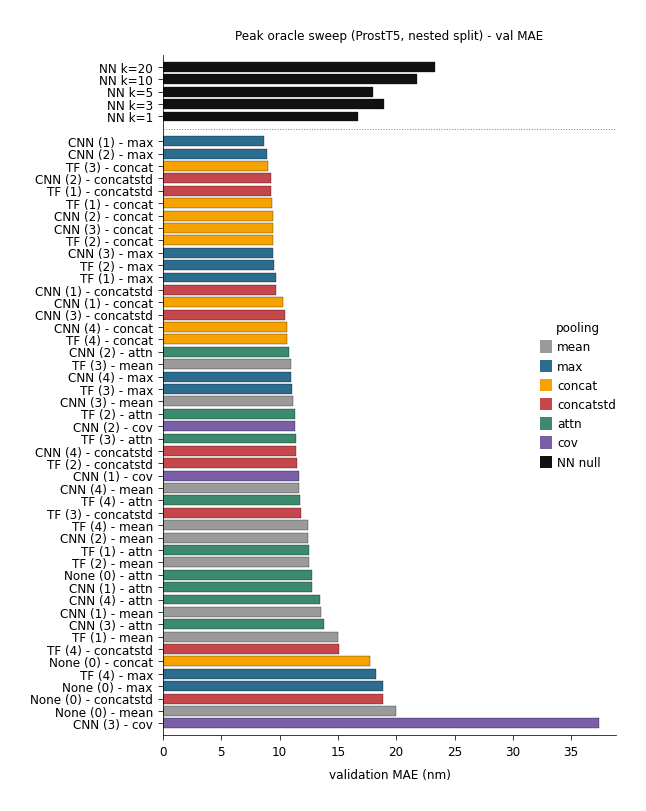

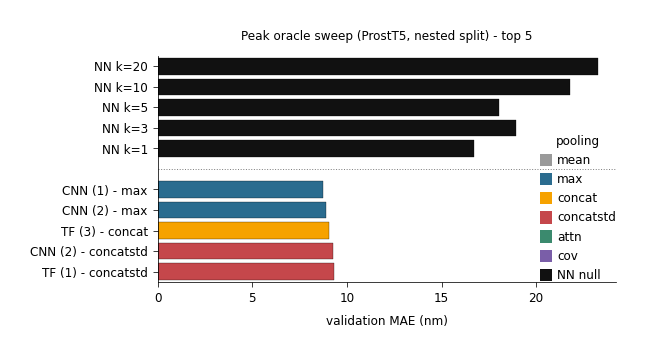

In [13]:
plot_bar(peak_orac, "nm", "Peak oracle sweep (ProstT5, nested split) - val MAE", nulls=embed_nulls("peak_oracle"))
plot_bar(peak_orac.iloc[0:5], "nm", "Peak oracle sweep (ProstT5, nested split) - top 5", nulls=embed_nulls("peak_oracle"))

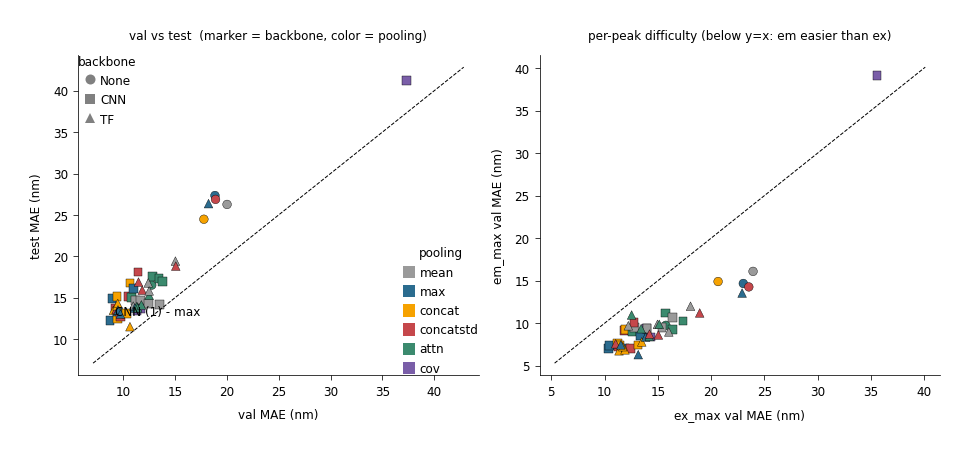

In [14]:
plot_scatter(peak_orac, "nm", per_peak=True)

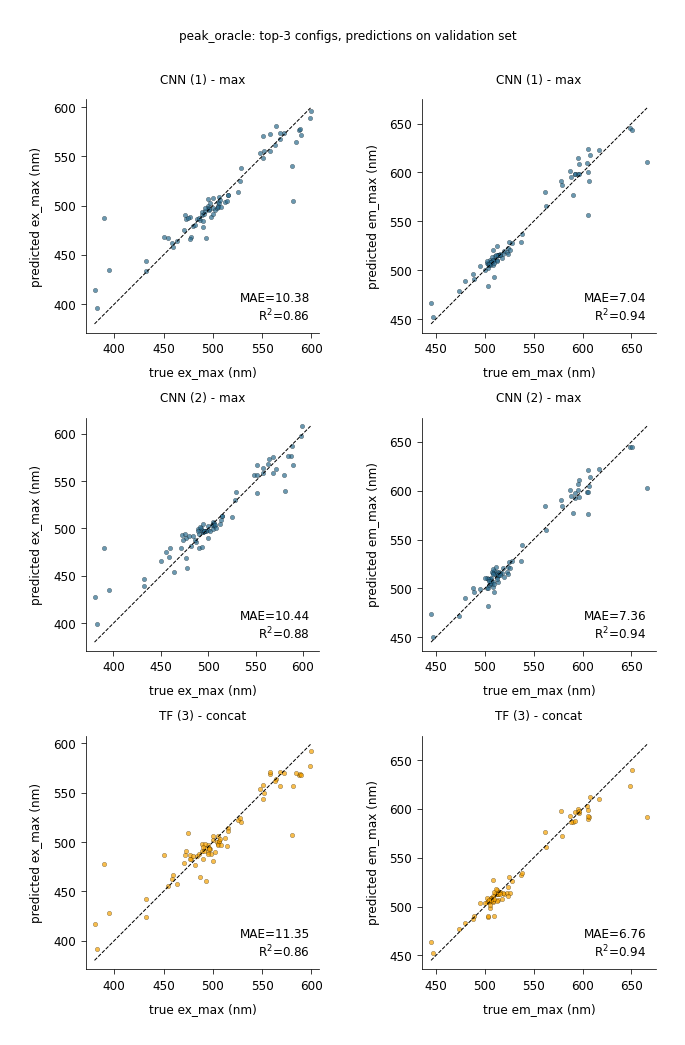

In [15]:
pred_vs_truth("peak_oracle", peak_orac, "trained_models/oracle_sweep")

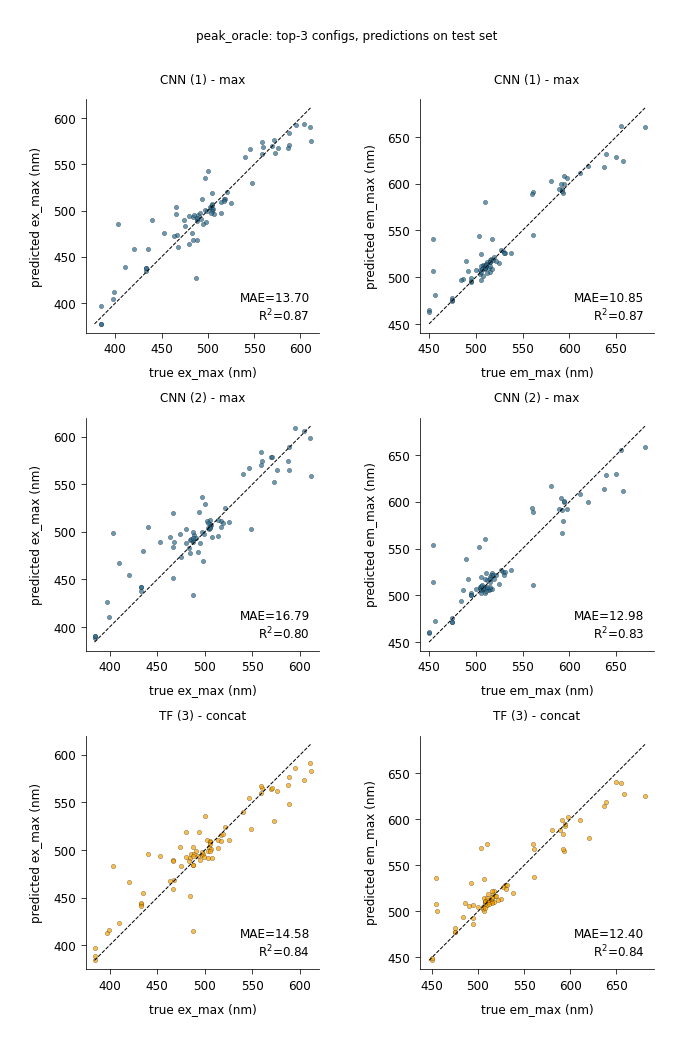

In [16]:
pred_vs_truth("peak_oracle", peak_orac, "trained_models/oracle_sweep", split="te")